# Perceptron — Learning from Data
PLA (Perceptron Learning Algorithm) aplicado ao dataset de dígitos.
Classificação binária: **dígito 1 vs todos**.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches


## 1. Carrega dados

In [2]:
train = np.loadtxt('digits.train')
test  = np.loadtxt('digits.test')

X_train, y_train = train[:, 1:], train[:, 0]
X_test,  y_test  = test[:, 1:],  test[:, 0]

# binário: 1 vs todos
y_train = np.where(y_train == 1, 1, -1)
y_test  = np.where(y_test  == 1, 1, -1)

print(f'Treino : {X_train.shape}  |  +1: {(y_train==1).sum()}  -1: {(y_train==-1).sum()}')
print(f'Teste  : {X_test.shape}   |  +1: {(y_test==1).sum()}   -1: {(y_test==-1).sum()}')


Treino : (7291, 2)  |  +1: 1005  -1: 6286
Teste  : (2007, 2)   |  +1: 264   -1: 1743


## 2. Perceptron (PLA)

In [3]:
class Perceptron:
    def __init__(self, n_iters=2000):
        self.n_iters = n_iters
        self.w = None
        self.b = None
        self.iters_run = 0

    def fit(self, X, y):
        n, d = X.shape
        self.w = np.zeros(d)
        self.b = 0.0
        for t in range(self.n_iters):
            preds = np.sign(X @ self.w + self.b)
            preds[preds == 0] = -1
            wrong = np.where(preds != y)[0]
            if len(wrong) == 0:
                self.iters_run = t
                break
            i = np.random.choice(wrong)
            self.w += y[i] * X[i]
            self.b += y[i]
        else:
            self.iters_run = self.n_iters

    def predict(self, X):
        out = np.sign(X @ self.w + self.b)
        out[out == 0] = -1
        return out

    def error(self, X, y):
        return np.mean(self.predict(X) != y)


## 3. Treina e avalia

In [4]:
np.random.seed(42)
model = Perceptron(n_iters=2000)
model.fit(X_train, y_train)

e_in  = model.error(X_train, y_train)
e_out = model.error(X_test,  y_test)

print(f'Iterações rodadas : {model.iters_run}')
print(f'E_in  (treino)    : {e_in:.4f}  ({e_in*100:.2f}%)')
print(f'E_out (teste)     : {e_out:.4f}  ({e_out*100:.2f}%)')


Iterações rodadas : 2000
E_in  (treino)    : 0.0151  (1.51%)
E_out (teste)     : 0.0214  (2.14%)


## 4. Fronteira de decisão

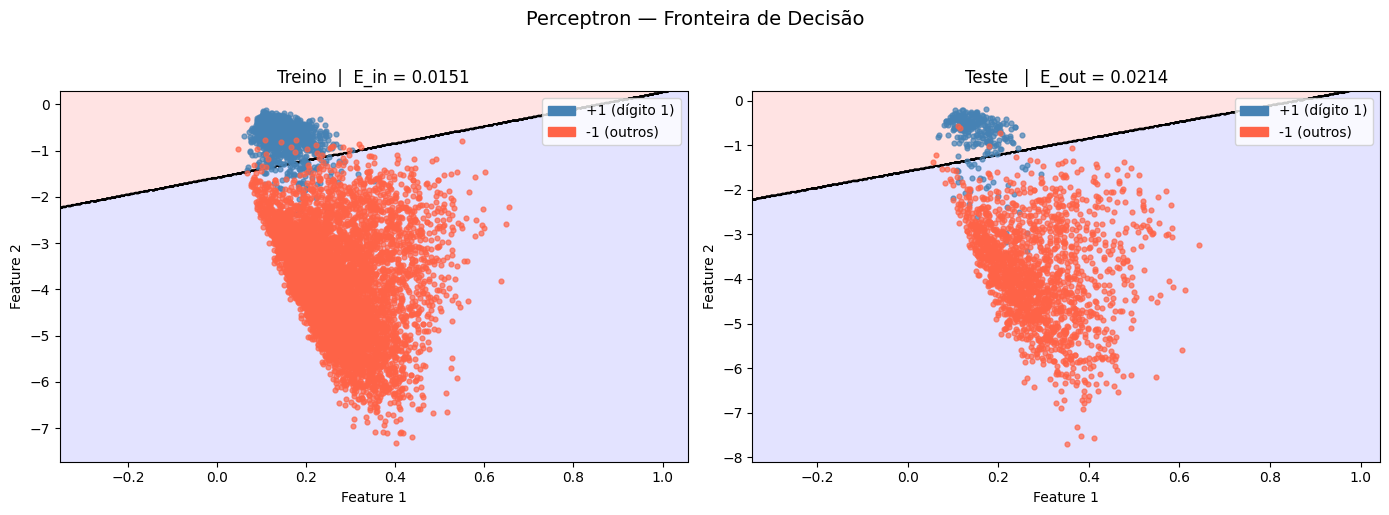

Plot salvo em fronteira_decisao.png


In [5]:
def plot_boundary(ax, X, y, title):
    margin = 0.4
    x1 = np.linspace(X[:,0].min()-margin, X[:,0].max()+margin, 400)
    x2 = np.linspace(X[:,1].min()-margin, X[:,1].max()+margin, 400)
    xx1, xx2 = np.meshgrid(x1, x2)
    Z = model.predict(np.c_[xx1.ravel(), xx2.ravel()]).reshape(xx1.shape)

    ax.contourf(xx1, xx2, Z, alpha=0.12, cmap='bwr')
    ax.contour(xx1, xx2, Z, colors='black', linewidths=1.2)

    pos = y == 1
    ax.scatter(X[pos,  0], X[pos,  1], c='steelblue', s=12, alpha=0.7, zorder=2)
    ax.scatter(X[~pos, 0], X[~pos, 1], c='tomato',    s=12, alpha=0.7, zorder=2)

    p1 = mpatches.Patch(color='steelblue', label='+1 (dígito 1)')
    p2 = mpatches.Patch(color='tomato',    label='-1 (outros)')
    ax.legend(handles=[p1, p2], loc='upper right')
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')
    ax.set_title(title, fontsize=12)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_boundary(axes[0], X_train, y_train==1, f'Treino  |  E_in = {e_in:.4f}')
plot_boundary(axes[1], X_test,  y_test==1,  f'Teste   |  E_out = {e_out:.4f}')
plt.suptitle('Perceptron — Fronteira de Decisão', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('fronteira_decisao.png', dpi=130, bbox_inches='tight')
plt.show()
print('Plot salvo em fronteira_decisao.png')
